In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Generazione di un dataset sintetico

Per questo esempio, creeremo un semplice dataset con due feature e due classi utilizzando `make_classification` di `scikit-learn`.

In [ ]:
from sklearn.datasets import make_classification

# Genera un dataset sintetico
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# Converti in DataFrame per facilità di visualizzazione
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

display(df.head())

,Feature_1,Feature_2,Target
0,0.601034,1.535353,1
1,0.755945,-1.172352,0
2,1.354479,-0.948528,0
3,3.103090,0.233485,0
4,0.753178,0.787514,1


### 2. Suddivisione del dataset in set di addestramento e test

Divideremo il dataset in un set di addestramento (80%) e un set di test (20%) per valutare le prestazioni del modello su dati non visti.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensione del set di addestramento: {X_train.shape[0]} samples")
print(f"Dimensione del set di test: {X_test.shape[0]} samples")

Dimensione del set di addestramento: 800 samples
Dimensione del set di test: 200 samples


### 3. Addestramento del modello

Utilizzeremo un semplice modello di Regressione Logistica, che è un algoritmo lineare per la classificazione.

In [ ]:
model = LogisticRegression(random_state=42)

# Addestra il modello sui dati di addestramento
model.fit(X_train, y_train)

print("Modello di Regressione Logistica addestrato con successo!")

Modello di Regressione Logistica addestrato con successo!


### 4. Valutazione del modello

Valuteremo le prestazioni del modello sul set di test utilizzando metriche come l'accuratezza, la matrice di confusione e il report di classificazione.

Accuratezza del modello: 0.90

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       104
           1       0.92      0.86      0.89        96

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200


Matrice di Confusione:
[[97  7]
 [13 83]]


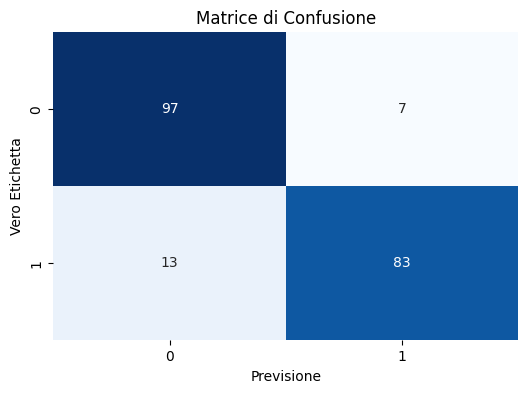

In [ ]:
# Effettua previsioni sul set di test
y_pred = model.predict(X_test)

# Calcola l'accuratezza
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuratezza del modello: {accuracy:.2f}")

# Report di classificazione
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred))

# Matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatrice di Confusione:")
print(conf_matrix)

# Visualizzazione della Matrice di Confusione
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Previsione')
plt.ylabel('Vero Etichetta')
plt.title('Matrice di Confusione')
plt.show()

### 5. Visualizzazione dei confini di decisione

Per un dataset 2D, possiamo visualizzare i punti dati e il confine di decisione appreso dal modello.

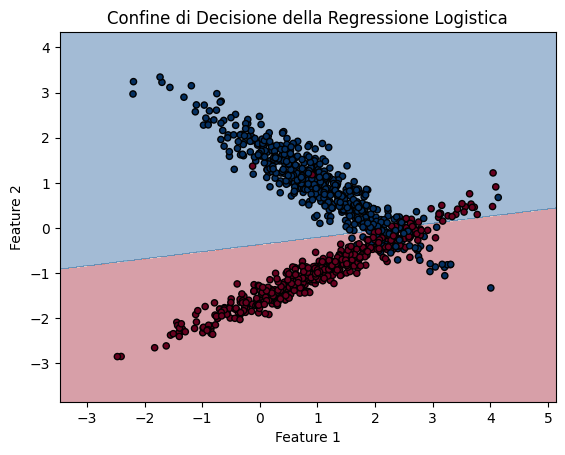

In [ ]:
# Visualizzazione dei confini di decisione (solo per 2 feature)
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdBu)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Confine di Decisione della Regressione Logistica')
    plt.show()

plot_decision_boundary(X, y, model)

### 6. Visualizzazione delle Curve di Probabilità e del Confine di Decisione

Per capire meglio come la regressione logistica opera, possiamo visualizzare le curve di probabilità predette dal modello. La "curva di flesso" in un contesto multi-dimensionale è la linea (o superficie) dove la probabilità di appartenere a una delle classi è esattamente 0.5. Questa linea coincide con il confine di decisione che abbiamo già visualizzato.

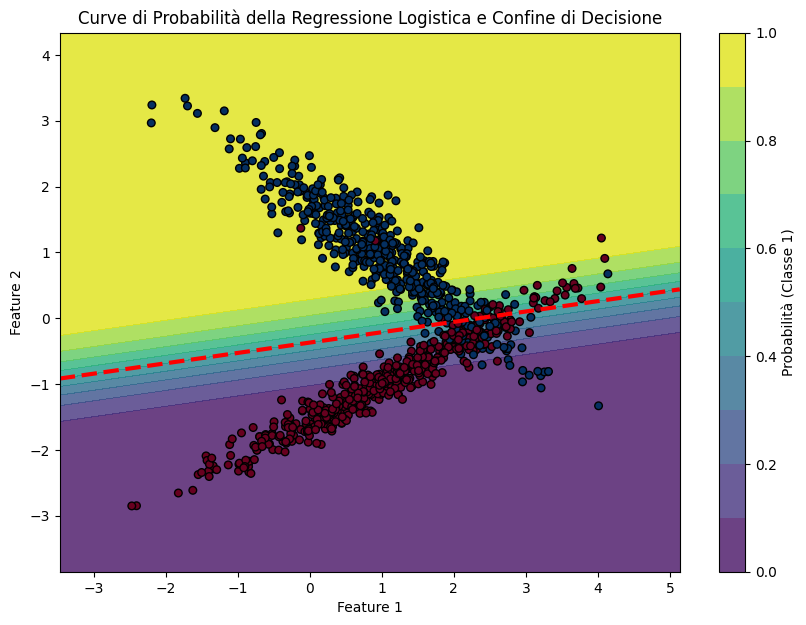

In [ ]:
# Visualizzazione delle curve di probabilità e del confine di decisione
def plot_probability_contours(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Prevedi le probabilità per la classe 1 (positiva) per ogni punto della griglia
    Z_proba = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z_proba = Z_proba.reshape(xx.shape)

    plt.figure(figsize=(10, 7))

    # Plot delle curve di probabilità (il 'grafico della regressione logistica' in 2D)
    contour = plt.contourf(xx, yy, Z_proba, alpha=0.8, cmap='viridis', levels=np.linspace(0, 1, 11))
    plt.colorbar(contour, label='Probabilità (Classe 1)')

    # Plot del contorno di probabilità 0.5 (il 'punto di flesso' / confine di decisione)
    plt.contour(xx, yy, Z_proba, levels=[0.5], colors='red', linewidths=3, linestyles='--')

    # Scatter plot dei punti dati originali
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap=plt.cm.RdBu)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Curve di Probabilità della Regressione Logistica e Confine di Decisione')
    plt.show()

plot_probability_contours(X, y, model)